In [1]:
import pandas as pd

df = pd.read_csv("./data/cleaned_datasets/cleaned_emails.csv")
df['text'] = df['text'].fillna("")

In [2]:
df.head()

,text,email_type,num_links,num_excl,num_caps,length
0,6 1100 disc uniformitarianism 1086 sex lang di...,0,0,0,0,594
1,side galicismos galicismo spanish term names i...,0,0,0,0,287
2,equistar deal tickets still available assist r...,0,0,0,0,786
3,hello hot lil horny toy one dream open minded ...,1,0,0,0,320
4,software incredibly low prices 86 lower draper...,1,0,0,0,361


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['email_type'],
    test_size=0.2,
    random_state=42
)


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [5]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

print("NB Accuracy:", nb.score(X_test_vec, y_test))


NB Accuracy: 0.9344355758266819


In [6]:
from sklearn.metrics import classification_report

pred = nb.predict(X_test_vec)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2213
           1       1.00      0.82      0.90      1295

    accuracy                           0.93      3508
   macro avg       0.95      0.91      0.93      3508
weighted avg       0.94      0.93      0.93      3508



In [7]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

print("LR Accuracy:", lr.score(X_test_vec, y_test))


LR Accuracy: 0.975769669327252


In [8]:
pred = lr.predict(X_test_vec)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2213
           1       0.97      0.96      0.97      1295

    accuracy                           0.98      3508
   macro avg       0.98      0.97      0.97      3508
weighted avg       0.98      0.98      0.98      3508



In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_vec, y_train)

print("RF Accuracy:", rf.score(X_test_vec, y_test))


RF Accuracy: 0.9751995438996579


In [10]:
pred = rf.predict(X_test_vec)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2213
           1       0.97      0.96      0.97      1295

    accuracy                           0.98      3508
   macro avg       0.97      0.97      0.97      3508
weighted avg       0.98      0.98      0.98      3508



In [11]:
print("NB:", nb.score(X_test_vec, y_test))
print("LR:", lr.score(X_test_vec, y_test))
print("RF:", rf.score(X_test_vec, y_test))

NB: 0.9344355758266819
LR: 0.975769669327252
RF: 0.9751995438996579


In [12]:
print("Naive Bayes")
print(classification_report(y_test, nb.predict(X_test_vec)))

print("Logistic Regression")
print(classification_report(y_test, lr.predict(X_test_vec)))

print("Random Forest")
print(classification_report(y_test, rf.predict(X_test_vec)))

Naive Bayes
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2213
           1       1.00      0.82      0.90      1295

    accuracy                           0.93      3508
   macro avg       0.95      0.91      0.93      3508
weighted avg       0.94      0.93      0.93      3508

Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2213
           1       0.97      0.96      0.97      1295

    accuracy                           0.98      3508
   macro avg       0.98      0.97      0.97      3508
weighted avg       0.98      0.98      0.98      3508

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2213
           1       0.97      0.96      0.97      1295

    accuracy                           0.98      3508
   macro avg       0.97      0.97      0.97      3508
weighted avg       0.98     

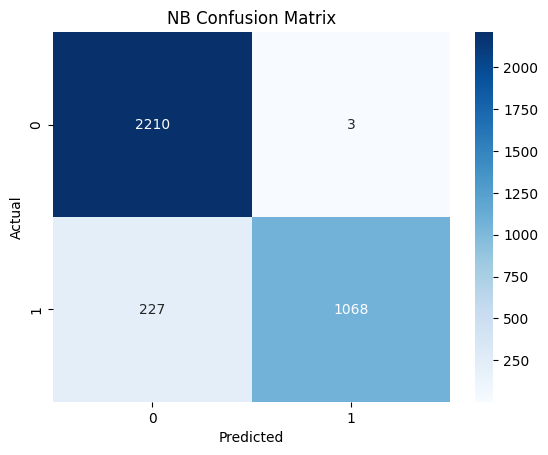

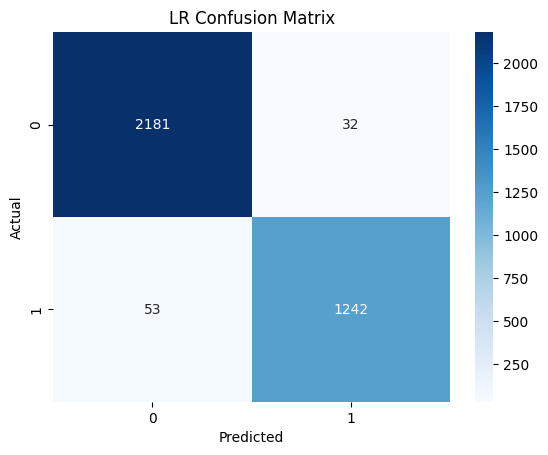

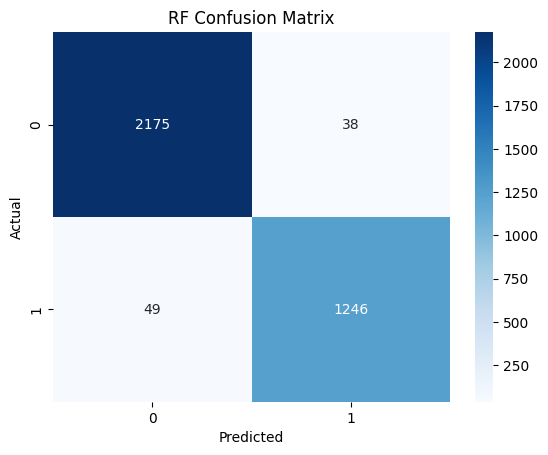

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {'NB': nb, 'LR': lr, 'RF': rf}

for name, model in models.items():
    cm = confusion_matrix(y_test, model.predict(X_test_vec))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [14]:
X_text = df['text']
X_numeric = df[['num_links', 'num_excl', 'num_caps', 'length']]
y = df['email_type']

In [15]:
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_text, X_numeric, y, test_size=0.2, random_state=42
)

In [16]:
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

In [17]:
from scipy.sparse import hstack

X_train_combined = hstack([X_train_vec, X_train_num])
X_test_combined = hstack([X_test_vec, X_test_num])

In [18]:
nb.fit(X_train_combined, y_train)
lr.fit(X_train_combined, y_train)
rf.fit(X_train_combined, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
print(nb.score(X_test_combined, y_test))
print(lr.score(X_test_combined, y_test))
print(rf.score(X_test_combined, y_test))

0.7844925883694412
0.9746294184720639
0.9737742303306728


In [20]:
print("Naive Bayes")
print(classification_report(y_test, nb.predict(X_test_combined)))

print("Logistic Regression")
print(classification_report(y_test, lr.predict(X_test_combined)))

print("Random Forest")
print(classification_report(y_test, rf.predict(X_test_combined)))

Naive Bayes
              precision    recall  f1-score   support

           0       0.75      0.99      0.85      2213
           1       0.95      0.44      0.60      1295

    accuracy                           0.78      3508
   macro avg       0.85      0.71      0.73      3508
weighted avg       0.82      0.78      0.76      3508

Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2213
           1       0.98      0.96      0.97      1295

    accuracy                           0.97      3508
   macro avg       0.97      0.97      0.97      3508
weighted avg       0.97      0.97      0.97      3508

Random Forest
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2213
           1       0.97      0.96      0.96      1295

    accuracy                           0.97      3508
   macro avg       0.97      0.97      0.97      3508
weighted avg       0.97     

In [23]:
import pickle

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("logreg.pkl", "wb") as f:
    pickle.dump(lr, f)

with open("randomforest.pkl", "wb") as f:
    pickle.dump(rf, f)